In [2]:
import pandas as pd

In [5]:
dataset = pd.read_csv(r"C:\Users\Manish Chahar\Desktop\internship\datasets\Titanic-Dataset.csv")

In [6]:
dataset.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [7]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
dataset["Age"]= dataset["Age"].fillna(dataset["Age"].median())
dataset["Cabin"]= dataset["Cabin"].fillna("unknown")
dataset['Embarked'] = dataset["Embarked"].fillna(dataset["Embarked"].mode()[0])

In [9]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [10]:
dataset.duplicated().sum()

0

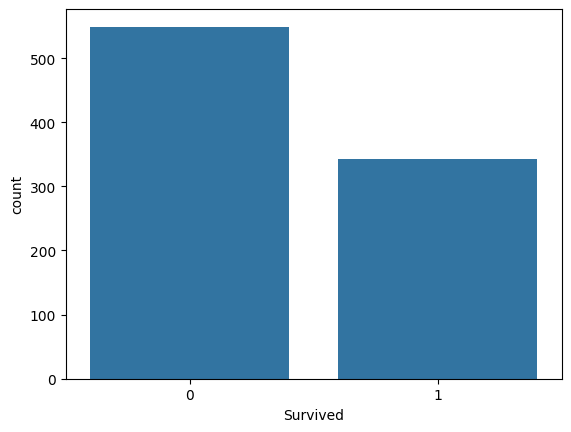

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=dataset)
plt.show()

In [12]:
dataset["Survived"] = dataset["Survived"].astype("category")

dataset["Pclass"] = dataset["Pclass"].astype("category")

dataset["Sex"] = dataset["Sex"].astype("category")

dataset["Embarked"] = dataset["Embarked"].astype("category")

In [13]:
dataset.dtypes


PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Cabin            object
Embarked       category
dtype: object

In [14]:
dataset = dataset.rename(columns={"PassengerId":"Passenger_Id","Pclass":"Passenger_Class"})

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

dataset["Sex"] = le.fit_transform(dataset["Sex"])
dataset["Embarked"] = le.fit_transform(dataset["Embarked"])

In [16]:
dataset = dataset.drop(columns={"Name","Ticket","Cabin"})

In [17]:
x = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=41)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

In [21]:
from sklearn.linear_model import LogisticRegression

In [22]:
model  = LogisticRegression()
model.fit(x_train,y_train)

c:\Users\Manish Chahar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [23]:
y_pred = model.predict(x_test)

In [24]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.7541899441340782


In [25]:
import pickle

In [26]:
pickle.dump(model, open("model.pkl", "wb"))